# **FINAL PROJECT** - Does AI Improve Customer Satisfaction?
## **Group 10**: Clément Guyot de La Pommeraye, Erik van der Sangen, Jacopo Cagnacci, Giacomo Bellodi​


## In this notebook we load, clean, merge and filter the datasets.

## **Import libraries**



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## **Load Complaints Data**


In [3]:
complaints = pd.read_csv(
    "/content/drive/MyDrive/complaints-2025-11-11_13_00.csv",
    engine="python",
    on_bad_lines="skip"
)
complaints.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,03/17/22,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the Fair Credit Reporting A...,NaN,"EQUIFAX, INC.",FL,32506,NaN,Consent provided,Web,03/17/22,Closed with explanation,Yes,NaN,5334586
1,06/09/20,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,"XXXX, XXXX SOC SEC # XXXX DOB XX/XX/1984 ADDRE...",NaN,"The Bureaus, Inc.",FL,33463,NaN,Consent provided,Web,06/09/20,Closed with explanation,Yes,NaN,3691217
2,08/15/24,Mortgage,Conventional home mortgage,Trouble during payment process,"Escrow, taxes, or insurance",I am writing to address a significant issue re...,NaN,"CMG Financial Services, Inc.",TX,77581,NaN,Consent provided,Web,08/15/24,Closed with explanation,Yes,NaN,9812241
3,02/24/25,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,I am filing a formal complaint against Fifth T...,NaN,FIFTH THIRD FINANCIAL CORPORATION,TN,37087,Servicemember,Consent provided,Web,02/24/25,Closed with explanation,Yes,NaN,12187007
4,06/27/21,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Seized or attempted to seize your property,Military star card has violated my consumer ri...,Company has responded to the consumer and the ...,Army and Air Force Exchange Service,TX,761XX,Servicemember,Consent provided,Web,06/27/21,Closed with explanation,No,NaN,4496008


In [15]:
print(f'The dataset contains: {len(complaints['Company'].unique())} unique companies (financial institutions).')
print(f'The number of conplaints in the dataset is: {len(complaints)}')

#compute average per company if compalints were uniformly distributed.
print(f"Average number of complaints per company: {len(complaints)/len(complaints['Company'].unique())}")


The dataset contains: 5319 unique companies (financial institutions).
The number of conplaints in the dataset is: 1378033
Average number of complaints per company: 259.07745816882874


The average number of complaints 259. Since we have 5319 unique companies, we need to subsample this large to list in order to label whether bank uses ChatBots or not. For this reasono we will only work with institutions that have more tha 260 complaints.

In [18]:
complaints['Company'].value_counts()[complaints['Company'].value_counts() > 260]
# percentage of complaints left if considering only those 233 companies.
complaints['Company'].value_counts()[complaints['Company'].value_counts() > 260].sum() / len(complaints)

np.float64(0.9382307970854109)

From more than 5000 companies we go to a much smaller number: 233. These 233 financial entities still account for 93% of total complaints.

Now we export the list of these 233 banks as we will then explore if they implement AI or not, and when.

In [21]:
companies_233 = complaints['Company'].value_counts()[complaints['Company'].value_counts() > 260]
companies_233.columns = ['Company', 'Number of complaints']
company_names_233 = companies_233.index
print(company_names_233)
pd.Series(company_names_233).to_csv('company_names_233.csv', index=False)

Index(['TRANSUNION INTERMEDIATE HOLDINGS, INC.', 'EQUIFAX, INC.',
       'Experian Information Solutions Inc.',
       'CAPITAL ONE FINANCIAL CORPORATION', 'JPMORGAN CHASE & CO.',
       'WELLS FARGO & COMPANY', 'BANK OF AMERICA, NATIONAL ASSOCIATION',
       'CITIBANK, N.A.', 'Block, Inc.', 'SYNCHRONY FINANCIAL',
       ...
       'STERLING JEWELERS, INC.', 'CrossCountry Mortgage LLC',
       'Paramount GR Holdings, LLC', 'TMX Finance LLC',
       'Franklin Collection Service, Inc.', 'Big Picture Loans, LLC',
       'Capital Accounts, LLC', 'Winklevoss Exchange LLC',
       'Bull City Financial Solutions, Inc',
       'PHH Mortgage Services Corporation'],
      dtype='object', name='Company', length=233)


##  **Load Income Data**

In [4]:
income = pd.read_csv("/content/drive/MyDrive/income_combined_2011-2023.csv")
income.head(5)

,GEOGRAPHY,ZIP CODE,NUMBER OF HOUSEHOLDS,MEDIAN INCOME GENERAL,PERCENTAGE WHITE,MEDIAN INCOME WHITE,PERCENTAGE BLACK,MEDIAN INCOME BLACK,PERCENTAGE NATIVE AMERICAN,MEDIAN INCOME NATIVE AMERICAN,...,MEDIAN INCOME WHITE ALONE NOT HISPANIC,PERCENTAGE HOUSEHOLDER 15-24 YO,MEDIAN INCOME HOUSEHOLDER 15-24 YO,PERCENTAGE HOUSEHOLDER 25-44 YO,MEDIAN INCOME HOUSEHOLDER 25-44 YO,PERCENTAGE HOUSEHOLDER 45-64 YO,MEDIAN INCOME HOUSEHOLDER 45-64 YO,PERCENTAGE HOUSEHOLDER 65+ YO,MEDIAN INCOME HOUSEHOLDER 65+ YO,Year
0,8600000US00601,ZCTA5 00601,5210.0,13318,92.7,13228,1.6,33385,0,-,...,3818,1,6250,23.2,15286,47.8,14257,28,12124,2011
1,8600000US00602,ZCTA5 00602,13500.0,14947,85.2,14766,4.4,12296,0.3,40069,...,20139,1.3,11648,30.7,15722,42.9,15160,25,14331,2011
2,8600000US00603,ZCTA5 00603,17958.0,14437,90.1,14495,2.8,11458,0.1,32639,...,32155,2.3,2604,27.1,16383,40.8,15791,29.9,13004,2011
3,8600000US00606,ZCTA5 00606,1679.0,11155,98,11123,0.3,"2,500-",0,-,...,-,0.8,20179,35.2,11895,42,12024,22,8622,2011
4,8600000US00610,ZCTA5 00610,9288.0,16367,92.3,16302,2.4,12757,0,-,...,37895,1.3,9167,28.3,17468,42,18963,28.5,13084,2011


In [5]:
print(complaints.columns)
print(income.columns)

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')
Index(['GEOGRAPHY', 'ZIP CODE', 'NUMBER OF HOUSEHOLDS',
       'MEDIAN INCOME GENERAL', 'PERCENTAGE WHITE', 'MEDIAN INCOME WHITE',
       'PERCENTAGE BLACK', 'MEDIAN INCOME BLACK', 'PERCENTAGE NATIVE AMERICAN',
       'MEDIAN INCOME NATIVE AMERICAN', 'PERCENTAGE ASIAN',
       'MEDIAN INCOME ASIAN', 'PERCENTAGE HAWAIIAN', 'MEDIAN INCOME HAWAIIAN',
       'PERCENTAGE OTHER RACE', 'MEDIAN INCOME OTHER RACE',
       'PERCENTAGE 2 OR MORE RACES', 'MEDIAN INCOME 2 OR MORE RACES',
       'PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'MEDIAN INCOME HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'PERCENTAGE

## **Merge data**

In [6]:
#crate new variable 'Year' in the df complaints to easier merge the complaints with the income.

complaints['Year'] = pd.to_datetime(complaints['Date received']).dt.year
complaints[['Date received', 'Year']]

/tmp/ipython-input-3977234801.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  complaints['Year'] = pd.to_datetime(complaints['Date received']).dt.year


,Date received,Year
0,03/17/22,2022
1,06/09/20,2020
2,08/15/24,2024
3,02/24/25,2025
4,06/27/21,2021
...,...,...
1378028,03/24/22,2022
1378029,11/19/23,2023
1378030,05/12/25,2025
1378031,03/25/22,2022


In [8]:
#create variable 'zip' that matches the format of 'ZIP CODE' in complaints
income['zip'] = income['ZIP CODE'].astype(str).str[-5:]
complaints.rename(columns={'ZIP code': 'zip'}, inplace=True)

In [9]:
#check if all zip codes in complaints are also in the income dataframe
are_all_complaint_zips_in_income = complaints['zip'].isin(income['zip']).all()
print(f"Are all 'zip' codes from 'complaints' present in 'income' DataFrame? {are_all_complaint_zips_in_income}")


Are all 'zip' codes from 'complaints' present in 'income' DataFrame? False


In [10]:
#understant which zip codes are not in the income dataframe
zips_not_in_income = complaints[~complaints['zip'].isin(income['zip'])]['zip'].unique()

print(f"Number of 'zip' codes in 'complaints' not found in 'income': {len(zips_not_in_income)}")
print("First 10 'zip' codes from 'complaints' not found in 'income':")
print(zips_not_in_income[:10])

Number of 'zip' codes in 'complaints' not found in 'income': 866
First 10 'zip' codes from 'complaints' not found in 'income':
['761XX' '666XX' '064XX' '027XX' '814XX' '163XX' '287XX' '145XX' '047XX'
 'XXXXX']


We noticed that some zip codes are masked by the user when filing the complaint, therefore we decide to drop them.

In [11]:
merged_df = complaints.merge(income, on = ['zip', 'Year'], how = 'inner')
print(f'Total complaints after merging: {len(merged_df)}')

Total complaints after merging: 491757


## **Descriptive statistics**

In [22]:
merged_df['Company'].value_counts()

,count
Company,
"EQUIFAX, INC.",85344
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",84864
Experian Information Solutions Inc.,81098
"BANK OF AMERICA, NATIONAL ASSOCIATION",11865
WELLS FARGO & COMPANY,11507
...,...
Accounts Interchange Group LLC,1
"MCCUE MORTGAGE COMPANY, THE",1
JLB CORPORATION,1


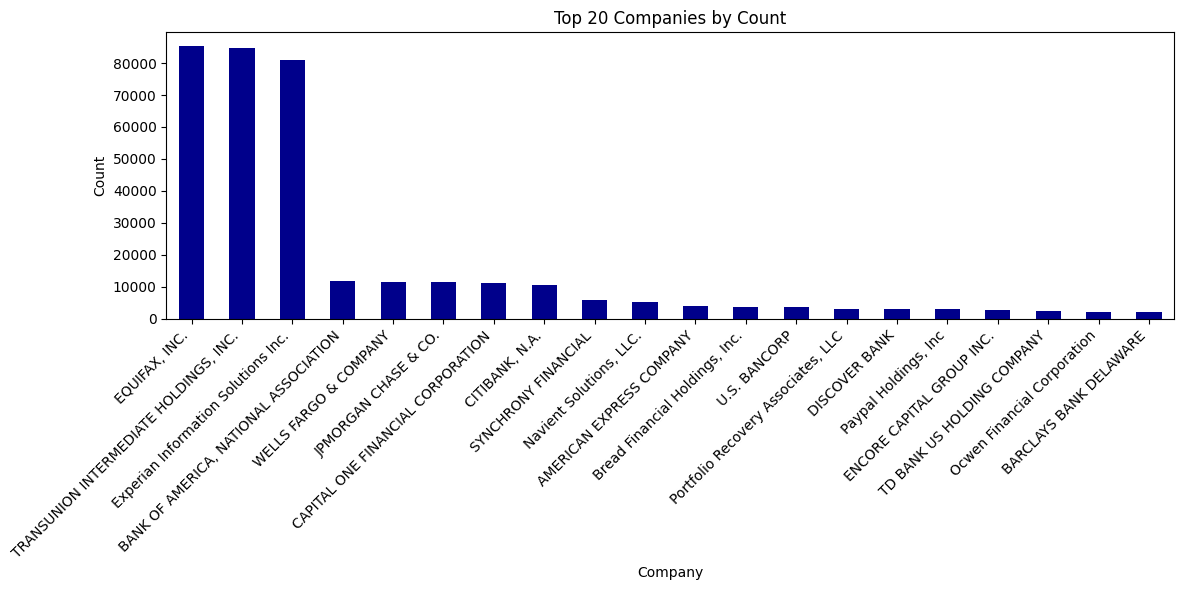

In [26]:
#top 20 companies by count
top20 = merged_df['Company'].value_counts().head(20)

# Plot
plt.figure(figsize=(12, 6))
top20.plot(kind='bar', color='darkblue')

plt.title("Top 20 Companies by Count")
plt.xlabel("Company")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


The 3 big Credit Bureaus account for 50% of the total complaints.

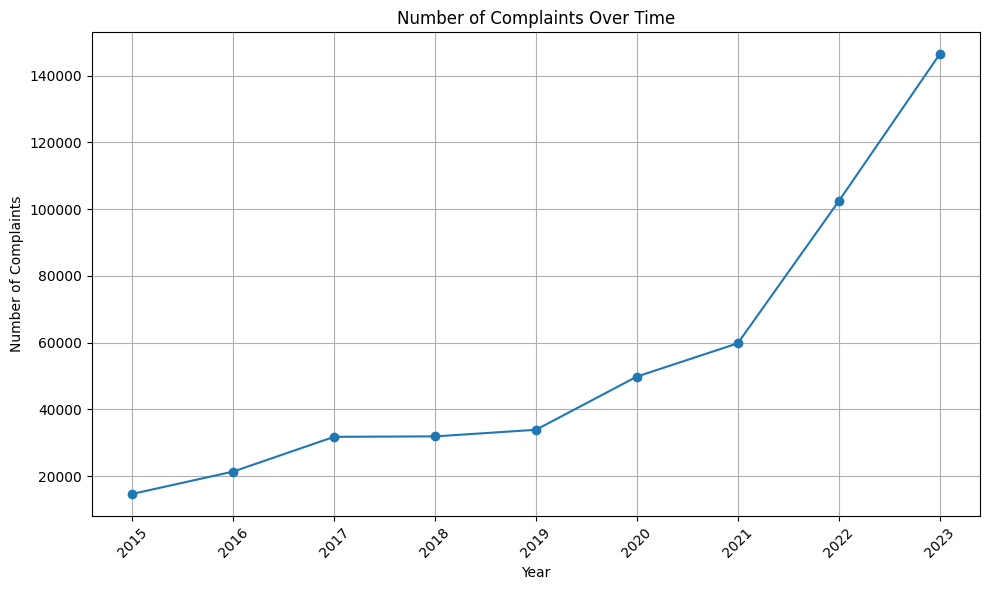

In [27]:
complaints_over_time = merged_df['Year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
complaints_over_time.plot(kind='line', marker='o')
plt.title('Number of Complaints Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Complaints')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
print(f'There are {len(merged_df['Issue'].unique())} unique Issues')
print(f'There are {len(merged_df['Sub-issue'].unique())} unique Sub-Issue')
print(f'There are {len(merged_df['Product'].unique())} unique Products')
print(f'There are {len(merged_df['Sub-product'].unique())} unique Sub-Products')
print(f'There are {len(merged_df['Tags'].unique())} unique tags')

There are 170 unique Issues
There are 262 unique Sub-Issue
There are 21 unique Products
There are 84 unique Sub-Products
There are 4 unique tags


In [30]:
print(merged_df['Product'].unique())
print(merged_df['Tags'].unique())


['Credit reporting, credit repair services, or other personal consumer reports'
 'Debt collection' 'Mortgage'
 'Credit reporting or other personal consumer reports'
 'Credit card or prepaid card'
 'Money transfer, virtual currency, or money service' 'Consumer Loan'
 'Vehicle loan or lease' 'Bank account or service' 'Credit reporting'
 'Checking or savings account' 'Credit card' 'Student loan'
 'Payday loan, title loan, or personal loan' 'Prepaid card'
 'Money transfers' 'Payday loan'
 'Payday loan, title loan, personal loan, or advance loan'
 'Other financial service' 'Debt or credit management' 'Virtual currency']
[nan 'Older American' 'Servicemember' 'Older American, Servicemember']


## **AI Labeling**

In the excel file, manual checks were done to address when the two LLMs were in disagreement. The model gpt 5.1 than Gemini Flash 2.5. The reason why ChatGPT variables and Gemini's concide is because we manually set them the same after veryfing online the 'true data'.

In [33]:
AI_label = pd.read_excel("/content/drive/MyDrive/banks_ai_label.xlsx", sheet_name= 'CHATGPT')
AI_label.head(5)

,Institution Name,ChatBot CHATGPT (Yes/No/Unknown),ChatBot GEMINI (Yes/No/Unknown),Chatbot Name CHATGPT,Chatbot Name GEMINI,Treatment Date (T0) CHAT GPT,Treatment Date (T0) GEMINI,Implication for study (CHATGPT)
0,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NO,NO,NaN,NaN,NaN,NaN,"Support options show phone, online forms and F..."
1,"EQUIFAX, INC.",NO,NO,–,NaN,NaN,NaN,Contact channels are phone and web forms; no s...
2,Experian Information Solutions Inc.,NO,NO,NaN,NaN,NaN,NaN,Databricks case study describes Experian build...
3,CAPITAL ONE FINANCIAL CORPORATION,Yes,Yes,Eno,Eno,2017-03-01 00:00:00,2017-03-01 00:00:00,"Capital One launched “Eno”, a natural-language..."
4,JPMORGAN CHASE & CO.,Yes,Yes,Chase Digital Assistant,Chase Digital Assistant,2020-11-01 00:00:00,2020-11-01 00:00:00,Consumer brand Chase introduced “Chase Digital...


In [34]:
#now apply some changes to the dataset (drop useless colums and fix date columns.)
AI_label.drop(columns=['ChatBot GEMINI (Yes/No/Unknown)', 'Chatbot Name GEMINI', 'Treatment Date (T0) GEMINI'], inplace=True)
AI_label.rename(columns={'ChatBot CHATGPT (Yes/No/Unknown)': 'AI adoption', 'Chatbot Name CHATGPT' : 'Chatbot name', 'Treatment Date (T0) CHAT GPT':'Date introduction'}, inplace=True)
AI_label.head()

,Institution Name,AI adoption,Chatbot name,Date introduction,Implication for study (CHATGPT)
0,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NO,NaN,NaN,"Support options show phone, online forms and F..."
1,"EQUIFAX, INC.",NO,–,NaN,Contact channels are phone and web forms; no s...
2,Experian Information Solutions Inc.,NO,NaN,NaN,Databricks case study describes Experian build...
3,CAPITAL ONE FINANCIAL CORPORATION,Yes,Eno,2017-03-01 00:00:00,"Capital One launched “Eno”, a natural-language..."
4,JPMORGAN CHASE & CO.,Yes,Chase Digital Assistant,2020-11-01 00:00:00,Consumer brand Chase introduced “Chase Digital...


In [35]:
#keep only companies we checked if they use or not AI
companies_to_keep = AI_label['Institution Name'].unique()
zip_data_16_23_filtered = merged_df[merged_df['Company'].isin(companies_to_keep)]

print(f"Original length of zip_data_16_23: {len(merged_df)}")
print(f"Length of zip_data_16_23 after filtering by AI_label['Institution Name']: {len(zip_data_16_23_filtered)}")
print(zip_data_16_23_filtered['Company'].value_counts())

Original length of zip_data_16_23: 491757
Length of zip_data_16_23 after filtering by AI_label['Institution Name']: 439847
Company
EQUIFAX, INC.                             85344
TRANSUNION INTERMEDIATE HOLDINGS, INC.    84864
Experian Information Solutions Inc.       81098
BANK OF AMERICA, NATIONAL ASSOCIATION     11865
WELLS FARGO & COMPANY                     11507
                                          ...  
Paramount GR Holdings, LLC                   88
Lockhart, Morris & Montgomery Inc.           84
Credit Control, LLC                          71
TekCollect Inc.                              57
Advanced Resolution Services Inc.            45
Name: count, Length: 208, dtype: int64
